A Gene-Expression Signature as a Predictor of Survival in Breast Cancer. The New England Journal of Medicine, 2002. https://www.nejm.org/doi/full/10.1056/NEJMoa021967

In [54]:
import os
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import matplotlib.ticker as ticker

from sksurv.util import Surv
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_selector, ColumnTransformer
from sksurv.ensemble import RandomSurvivalForest, GradientBoostingSurvivalAnalysis
from SurvSet.data import SurvLoader

import shapiq 

import src

SEED = 1234
np.random.seed(SEED)

In [5]:
N_TIMEPOINTS = 31

In [13]:
loader = SurvLoader()
enc_num = Pipeline(steps=[('impute', SimpleImputer(strategy='median'))])
sel_num = make_column_selector(pattern='^num\\_')
enc_fac = Pipeline(steps=[('ohe', OneHotEncoder(drop="first", sparse_output=False, handle_unknown='ignore'))])
sel_fac = make_column_selector(pattern='^fac\\_')
enc_df = ColumnTransformer(transformers=[('num', enc_num, sel_num), ('ohe', enc_fac, sel_fac)])
enc_df.set_output(transform='pandas')
df = loader.load_dataset(ds_name="nki70")['df'].set_index("pid")
senc = Surv()
So = senc.from_arrays(df['event'].astype(bool), df['time'])
enc_df.fit(df)
X_train = enc_df.transform(df)
X_train.columns = X_train.columns.str.replace("num__num_", "")
X_train.columns = X_train.columns.str.replace("ohe__fac_", "")
model = RandomSurvivalForest(max_depth=5, n_estimators=300, oob_score=True, random_state=SEED)
model.fit(X=X_train.values, y=So)
timepoints = src.get_evenly_spaced_integers(model.unique_times_, N_TIMEPOINTS)

In [14]:
print(f'train score: {model.score(X_train.values, So):.04f} | OOB score: {model.oob_score_:.04f}')

train score: 0.9541 | OOB score: 0.7261


In [34]:
temp = []
for id in range(144):
    filename = f'/mnt/evafs/groups/mi2lab/hbaniecki/survshapiq/nki70_v2/order1_id{id}.pkl'
    if os.path.isfile(filename):
        with open(filename, 'rb') as f:
            df = pickle.load(f)
            df = df.assign(id=id, time=timepoints)
            df = pd.melt(df, id_vars=['time', 'id'], var_name="feature")
            df = df.assign(color=X_train.iloc[[id]].values.repeat(N_TIMEPOINTS))
            temp.append(df)
            
df_plot1 = pd.concat(temp, axis=0)

temp = []
for id in range(144):
    filename = f'/mnt/evafs/groups/mi2lab/hbaniecki/survshapiq/nki70_v2/order2_id{id}.pkl'
    if os.path.isfile(filename):
        with open(filename, 'rb') as f:
            df = pickle.load(f)
            df = df.assign(id=id, time=timepoints)
            df = pd.melt(df, id_vars=['time', 'id'], var_name="feature")
            # df = df.assign(color=X_train.iloc[[id]].values.repeat(N_TIMEPOINTS))
            temp.append(df)
df_plot2 = pd.concat(temp, axis=0)
df_plot2 = df_plot2.assign(is_interaction=df_plot2['feature'].str.contains('*', regex=False))

In [15]:
k = 4
topk_features = df_plot1.groupby('feature').agg({'value': 'std'}).sort_values('value', ascending=False).head(k).index.tolist()

In [67]:
topk_features

['ZNF533', 'PRC1', 'QSCN6L1', 'RFC4']

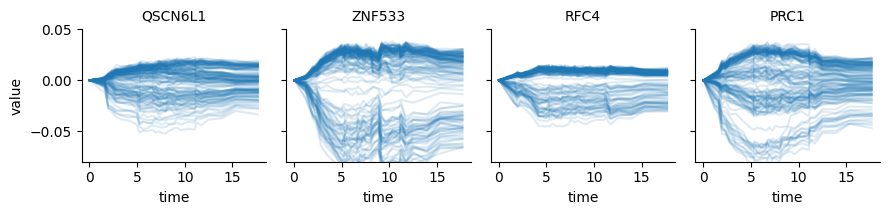

In [16]:
ax = sns.relplot(
    df_plot1[df_plot1['feature'].isin(topk_features)], 
    x="time", y="value", col="feature", kind="line", units="id", 
    estimator=None, alpha=0.15, 
    height=2.25,
    aspect=1,
    col_wrap=4
    # hue="treatment", palette=sns.color_palette("tab10")
)
ax.set(ylim=(-0.08, 0.05))
# ax.fig.suptitle(" ", y=0.95)
# sns.move_legend(ax, loc="upper left", bbox_to_anchor=(1, 1))
# plt.title(f'')
ax.set_titles(col_template="{col_name}")
plt.tight_layout()
# plt.savefig(f'results/nki70_order1_global.png', bbox_inches="tight")
# plt.clf()

In [ ]:
for feature_name in df_plot1.feature.unique():
    temp = df_plot1[df_plot1.feature == feature_name]
    fig, ax = plt.subplots(figsize=(3, 1.75))

    CMAP = "coolwarm"

    for id_val in temp.id.unique():
        line_data = temp[temp.id == id_val].sort_values(by="time")
        x = line_data["time"].values
        y = line_data["value"].values
        c = line_data["color"].values

        # Create line segments with color
        points = np.array([x, y]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)

        lc = LineCollection(
            segments,
            cmap=CMAP, # coolwarm
            norm=plt.Normalize(temp.color.min(), temp.color.max()),
            array=c[:-1],  # color values
            linewidth=1,
            alpha=0.5
        )
        ax.add_collection(lc)

    ax.set_xlim(0, 305)
    ax.set_ylim(-0.22, 0.13)
    ax.set_title("$\mathbf{" + feature_name + "}$ (order 1)")
    # if feature_name == "age":
    #     ax.set_xlabel('Time')
    #     ax.set_ylabel(' ')
    if feature_name in ["karnof", "priorzdv"]:
        ax.set_ylabel('Attribution')
    # if feature_name == "priorzdv":
    #     ax.set_xlabel(' ')
    #     ax.set_ylabel(' ')
    # if feature_name == "cd4":
    #     ax.set_xlabel('Time')
    #     ax.set_ylabel('Attribution')

    # Add colorbar
    sm = plt.cm.ScalarMappable(cmap=CMAP, norm=plt.Normalize(temp.color.quantile(0.00), temp.color.quantile(0.95), clip=True))
    sm.set_array([])  # required for colorbar
    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    # cbar.set_label("color value")
    # plt.tight_layout()
    plt.savefig(f'results/actg_order1_global_{feature_name}.pdf', bbox_inches="tight", pad_inches=0.01)
    # plt.close()

### interactions

In [26]:
# df_plot2.groupby('is_interaction').agg({'value': lambda x: x.abs().max()})

In [85]:
# features_ranked = df_plot2.groupby('feature').agg({'value': lambda value: value.std()}).sort_values('value', ascending=False).index.tolist()
features_ranked = df_plot2.groupby('feature').agg({'value': lambda value: value.abs().sum()}).sort_values('value', ascending=False).index.tolist()

In [86]:
# features_ranked[:77]

In [87]:
k = 4
topk_interactions = [x for x in features_ranked if x.find("*") != -1][:k]
topk_firstorder = [x for x in features_ranked if x.find("*") == -1][:k]

In [88]:
features_ranked[:4]

['ZNF533', 'PRC1', 'QSCN6L1', 'RFC4']

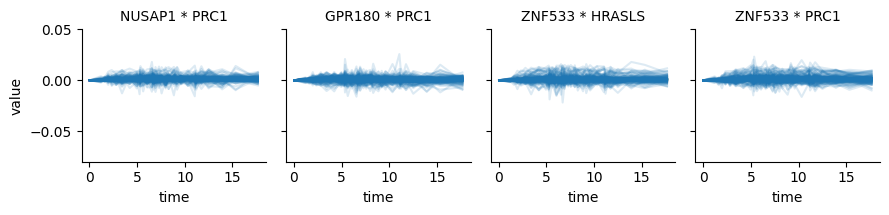

In [89]:
ax = sns.relplot(
    df_plot2[df_plot2['feature'].isin(topk_interactions)], 
    x="time", y="value", col="feature", kind="line", units="id", 
    estimator=None, alpha=0.15, 
    height=2.25,
    aspect=1,
    col_wrap=4
    # hue="treatment", palette=sns.color_palette("tab10")
)
ax.set(ylim=(-0.08, 0.05))
# ax.fig.suptitle(" ", y=0.95)
# sns.move_legend(ax, loc="upper left", bbox_to_anchor=(1, 1))
# plt.title(f'')
ax.set_titles(col_template="{col_name}")
plt.tight_layout()
# plt.savefig(f'results/nki70_order2_global.png', bbox_inches="tight")
# plt.clf()

In [90]:
for feature_name in topk_firstorder:
    temp = df_plot2[df_plot2.feature == feature_name]
    break
temp

,time,id,feature,value,is_interaction
1023,0.054757,0,ZNF533,0.000000,False
1024,1.210130,0,ZNF533,0.001578,False
1025,1.612594,0,ZNF533,0.003383,False
1026,1.973990,0,ZNF533,0.008297,False
1027,2.340862,0,ZNF533,0.016040,False
...,...,...,...,...,...
1049,11.739904,143,ZNF533,-0.063407,False
1050,12.503765,143,ZNF533,-0.060992,False
1051,13.919233,143,ZNF533,-0.059024,False
1052,15.329227,143,ZNF533,-0.046356,False


In [93]:
for feature_name in topk_firstorder:
    temp = df_plot2[df_plot2.feature == feature_name]
    temp = temp.assign(color=X_train[[feature_name]].values.repeat(N_TIMEPOINTS))
    fig, ax = plt.subplots(figsize=(3, 1.75))

    CMAP = "coolwarm"

    for id_val in temp.id.unique():
        line_data = temp[temp.id == id_val].sort_values(by="time")
        x = line_data["time"].values
        y = line_data["value"].values
        c = line_data["color"].values

        # Create line segments with color
        points = np.array([x, y]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)

        lc = LineCollection(
            segments,
            cmap=CMAP, # coolwarm
            norm=plt.Normalize(temp.color.min(), temp.color.max()),
            array=c[:-1],  # color values
            linewidth=1,
            alpha=0.5
        )
        ax.add_collection(lc)

    ax.set_xlim(0, 16)
    ax.set_ylim(-0.10, 0.05)
    ax.set_title("$\mathbf{" + feature_name + "}$ (order 2)")
    # ax.set_xlabel('Time')
    if feature_name in ["ZNF533"]:
        ax.set_ylabel('Attribution')

    # Add colorbar
    sm = plt.cm.ScalarMappable(cmap=CMAP, norm=plt.Normalize(temp.color.quantile(0.01), temp.color.quantile(0.99), clip=True))
    sm.set_array([])  # required for colorbar
    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.locator = ticker.MaxNLocator(nbins=3, min_n_ticks=3)
    cbar.update_ticks()
    # cbar.set_label("color value")
    plt.savefig(f'results/nki70_order2_global_{feature_name}.pdf', bbox_inches="tight", pad_inches=0.01)
    plt.close()

In [92]:
for feature_name in topk_interactions:
    feat1 = feature_name.split(" * ")[0]
    feat2 = feature_name.split(" * ")[1]
    temp = df_plot2[df_plot2.feature == feature_name]
    temp = temp.assign(color=X_train[[feat2]].values.repeat(N_TIMEPOINTS))
    fig, ax = plt.subplots(figsize=(3, 1.75))

    CMAP = "coolwarm"

    for id_val in temp.id.unique():
        line_data = temp[temp.id == id_val].sort_values(by="time")
        x = line_data["time"].values
        y = line_data["value"].values
        c = line_data["color"].values

        # Create line segments with color
        points = np.array([x, y]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)

        lc = LineCollection(
            segments,
            cmap=CMAP, # coolwarm
            norm=plt.Normalize(temp.color.min(), temp.color.max()),
            array=c[:-1],  # color values
            linewidth=1,
            alpha=0.5
        )
        ax.add_collection(lc)

    ax.set_xlim(0, 16)
    ax.set_ylim(-0.10, 0.05)
    ax.set_title("$\mathbf{" + feat1 + "} \\times\mathbf{" + feat2 + "}$ (color)")
    ax.set_xlabel('Time')
    if feature_name in ["ZNF533 * PRC1"]:
        ax.set_ylabel('Attribution')

    # Add colorbar
    sm = plt.cm.ScalarMappable(cmap=CMAP, norm=plt.Normalize(temp.color.quantile(0.01), temp.color.quantile(0.99), clip=True))
    sm.set_array([])  # required for colorbar
    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.locator = ticker.MaxNLocator(nbins=3, min_n_ticks=3)
    cbar.update_ticks()
    # cbar.set_label("color value")
    plt.savefig(f'results/nki70_order2_global_{feature_name.replace(" * ", "-")}.pdf', bbox_inches="tight", pad_inches=0.01)
    plt.close()